# Email Spam Detection Using Natural Language Processing

## Team Members

1. Nur Adina binti Zahrulkamar
2. Laila Khadija binti Mohd Nazri
3. Kesshi Akshainie Thevi A/P Saravanan
4. Nurin Afiqah Binti Rosman

## Project Overview

This project develops an Email Spam Detection system using Natural Language Processing (NLP) and Machine Learning techniques. The objective is to classify messages into Spam and Ham (Not Spam) categories. The SMS Spam Collection Dataset containing 5,572 messages was used for model training and evaluation.

## Objectives

1. To preprocess and clean text data using NLP techniques.
2. To implement Bag of Words and TF-IDF feature extraction methods.
3. To compare the performance of Naive Bayes and K-Nearest Neighbors (KNN) classifiers.
4. To develop an intelligent spam detection application.
5. To evaluate model performance using accuracy, precision, recall, F1-score, and confusion matrix.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
### Imports ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import pickle
from collections import Counter

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

In [3]:
### Download NLTK ###
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
### Extract Dataset ###

import zipfile

zip_path = "/content/drive/MyDrive/NLP-Spam-Detector/dataset/archive (6).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/spam_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
### Load Dataset ###

import pandas as pd

df = pd.read_csv(
    '/content/spam_dataset/spam.csv',
    encoding='latin-1'
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
### Data Cleaning ###

df = df[['v1','v2']]

df.columns = [
    'label',
    'message'
]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
### Dataset Information ###
# Display the first 5 rows of the dataset
print("First 5 Rows:")
print(df.head())

print("\n")

# Display all column names
print("Column Names:")
print(df.columns)

print("\n")

# Display number of rows and columns
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n")

# Display dataset information such as data types and non-null counts
print("Dataset Information:")
df.info()

print("\n")

# Check for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

First 5 Rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Column Names:
Index(['label', 'message'], dtype='object')


Dataset Shape (Rows, Columns):
(5572, 2)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Missing Values:
label      0
message    0
dtype: int64


In [8]:
### Class Distribution ###

df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [9]:
### Label Encoding ###

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(
    df['label']
)

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
### Preprocessing Function ###

ps = PorterStemmer()

def transform_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z]',
        ' ',
        text
    )

    words = text.split()

    words = [
        ps.stem(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [11]:
### Apply Preprocessing ###

df['processed'] = df['message'].apply(
    transform_text
)

df.head()

,label,message,processed
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [12]:
### Feature Extraction #1 - Bag of Words ###

cv = CountVectorizer(
    max_features=5000
)

X_bow = cv.fit_transform(
    df['processed']
)

y = df['label'].values

print("BoW Shape:", X_bow.shape)

BoW Shape: (5572, 5000)


In [13]:
### Feature Extraction #2 - TF-IDF ###

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(
    df['processed']
)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (5572, 5000)


In [14]:
### Train Test Split ###

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train_tfidf.shape)
print("Testing Size:", X_test_tfidf.shape)

Training Size: (4457, 5000)
Testing Size: (1115, 5000)


In [15]:
### TRAIN 4 MODELS ###

# BoW + Naive Bayes
bow_nb = MultinomialNB()
bow_nb.fit(X_train_bow, y_train)
bow_nb_pred = bow_nb.predict(X_test_bow)

# BoW + KNN
bow_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

bow_knn.fit(X_train_bow, y_train)
bow_knn_pred = bow_knn.predict(X_test_bow)

# TF-IDF + Naive Bayes
tfidf_nb = MultinomialNB()
tfidf_nb.fit(X_train_tfidf, y_train)
tfidf_nb_pred = tfidf_nb.predict(X_test_tfidf)

# TF-IDF + KNN
tfidf_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

tfidf_knn.fit(X_train_tfidf, y_train)
tfidf_knn_pred = tfidf_knn.predict(X_test_tfidf)

print("All models trained successfully!")

All models trained successfully!


In [16]:
### MODEL EVALUATION ###

models = {
    "BoW + Naive Bayes": bow_nb_pred,
    "BoW + KNN": bow_knn_pred,
    "TF-IDF + Naive Bayes": tfidf_nb_pred,
    "TF-IDF + KNN": tfidf_knn_pred
}

results = []

for name, pred in models.items():

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,pred))

    print("\nClassification Report")
    print(classification_report(y_test,pred))

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

results_df



BoW + Naive Bayes
Accuracy : 0.9812
Precision: 0.9156
Recall   : 0.9463
F1 Score : 0.9307

Confusion Matrix
[[953  13]
 [  8 141]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.92      0.95      0.93       149

    accuracy                           0.98      1115
   macro avg       0.95      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



BoW + KNN
Accuracy : 0.9444
Precision: 1.0
Recall   : 0.5839
F1 Score : 0.7373

Confusion Matrix
[[966   0]
 [ 62  87]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       966
           1       1.00      0.58      0.74       149

    accuracy                           0.94      1115
   macro avg       0.97      0.79      0.85      1115
weighted avg       0.95      0.94      0.94      1115



TF-IDF + Naive Bayes
Accuracy : 0.974
Preci

,Model,Accuracy,Precision,Recall,F1
0,BoW + Naive Bayes,0.981166,0.915584,0.946309,0.930693
1,BoW + KNN,0.944395,1.000000,0.583893,0.737288
2,TF-IDF + Naive Bayes,0.973991,0.991803,0.812081,0.892989
3,TF-IDF + KNN,0.944395,1.000000,0.583893,0.737288


In [17]:
### BEST MODEL ###

best_row = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print(best_row)

best_model_name = best_row['Model']

print("\nBest Model:")
print(best_model_name)

Model        BoW + Naive Bayes
Accuracy              0.981166
Precision             0.915584
Recall                0.946309
F1                    0.930693
Name: 0, dtype: object

Best Model:
BoW + Naive Bayes


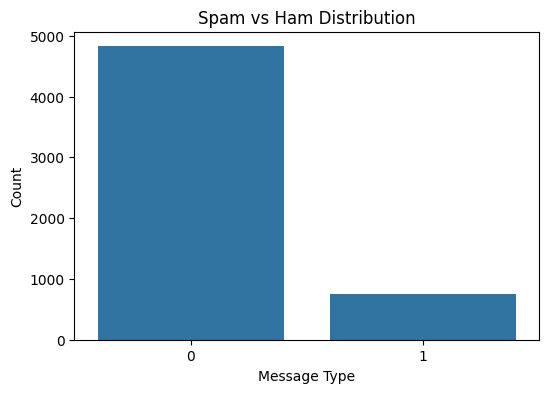

In [18]:
### VISUALIZATION 1 ###
### Class Distribution ###

plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title('Spam vs Ham Distribution')
plt.xlabel('Message Type')
plt.ylabel('Count')

plt.show()

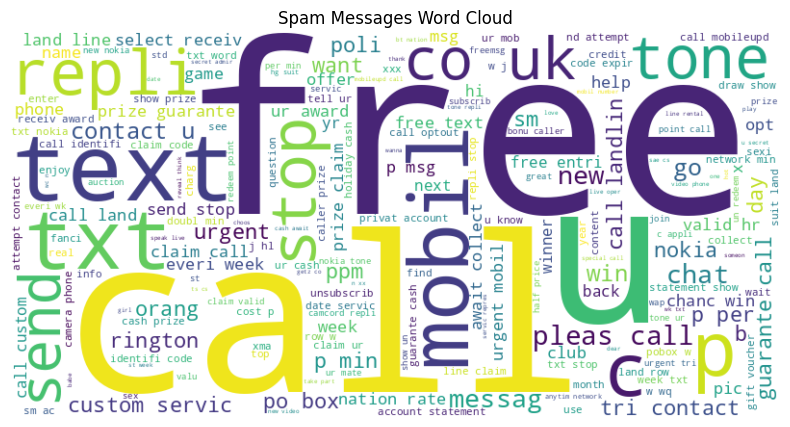

In [19]:
### VISUALIZATION 2 ###
### Spam Word Cloud ###

spam_text = " ".join(
    df[df['label']==1]['processed']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('Spam Messages Word Cloud')

plt.show()

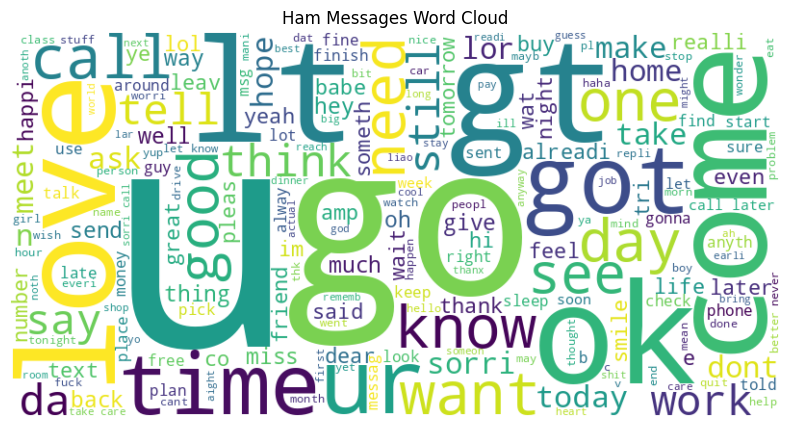

In [20]:
### VISUALIZATION 3 ###
### Ham Word Cloud ###

ham_text = " ".join(
    df[df['label']==0]['processed']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('Ham Messages Word Cloud')

plt.show()

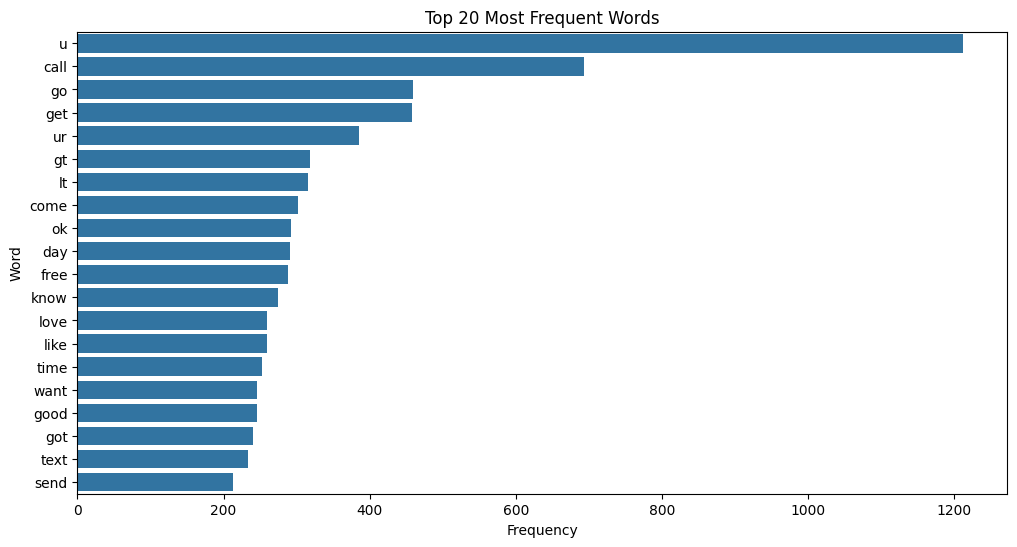

In [21]:
### VISUALIZATION 4 ###
### Top 20 Words ###

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all processed words from all messages
all_words = []

for message in df['processed']:
    words = message.split()
    all_words.extend(words)

# Count word frequencies
word_counts = Counter(all_words)

# Get top 20 most frequent words
top20_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Word', 'Frequency']
)


# Create bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=top20_words,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

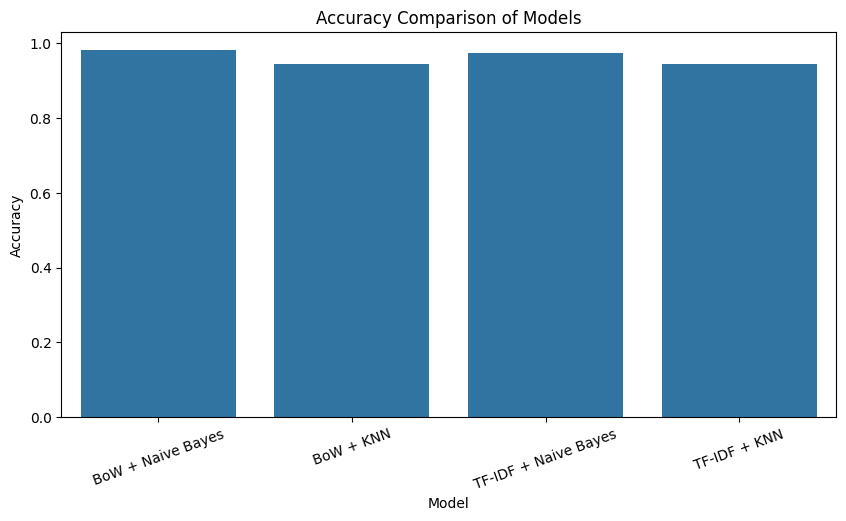

In [22]:
### VISUALIZATION 5 ###
### Model Accuracy Comparison ###

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title('Accuracy Comparison of Models')

plt.xticks(rotation=20)

plt.show()

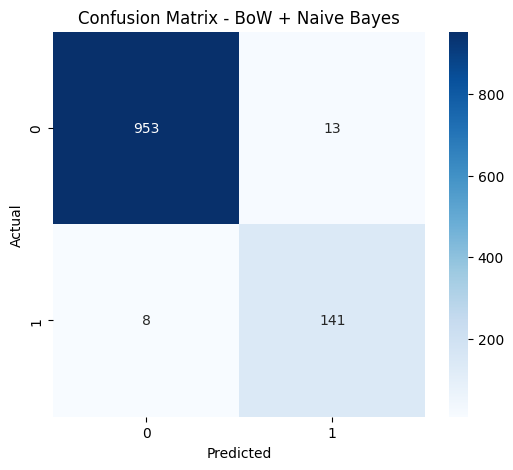

In [33]:
### VISUALIZATION 6 ###
### Best Model Confusion Matrix ###

cm = confusion_matrix(
    y_test,
    bow_nb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - BoW + Naive Bayes')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

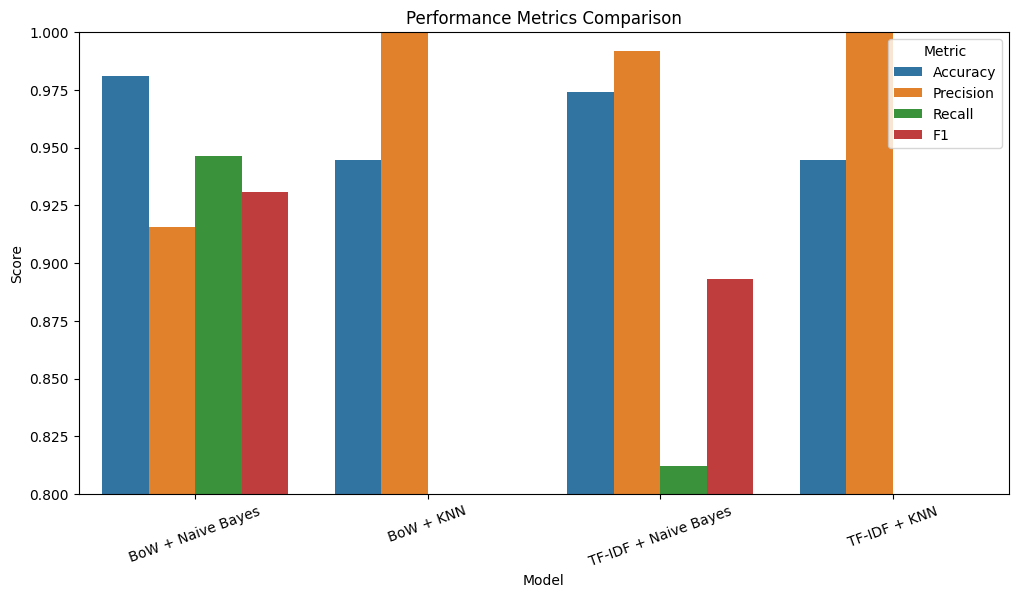

In [32]:
### VISUALIZATION 7 ###
### Performance Metrics Comparison ###

metrics_df = results_df.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=metrics_df,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Performance Metrics Comparison')

plt.ylim(0.8,1.0)

plt.xticks(rotation=20)

plt.show()

In [25]:
### SAVE BEST MODEL ###

if best_model_name == "TF-IDF + Naive Bayes":

    final_model = tfidf_nb
    final_vectorizer = tfidf

elif best_model_name == "TF-IDF + KNN":

    final_model = tfidf_knn
    final_vectorizer = tfidf

elif best_model_name == "BoW + Naive Bayes":

    final_model = bow_nb
    final_vectorizer = cv

else:

    final_model = bow_knn
    final_vectorizer = cv

pickle.dump(
    final_model,
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/best_model.pkl',
        'wb'
    )
)

pickle.dump(
    final_vectorizer,
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/vectorizer.pkl',
        'wb'
    )
)

print("Best model saved!")

Best model saved!


In [26]:
### LOAD BEST MODEL ###

loaded_model = pickle.load(
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/best_model.pkl',
        'rb'
    )
)

loaded_vectorizer = pickle.load(
    open(
        '/content/drive/MyDrive/NLP-Spam-Detector/models/vectorizer.pkl',
        'rb'
    )
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [27]:
### Test Saved Model : Spam Example ###

sample_message = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize."
]

processed_sample = transform_text(
    sample_message[0]
)

sample_vector = loaded_vectorizer.transform(
    [processed_sample]
)

prediction = loaded_model.predict(
    sample_vector
)

print("Prediction:", prediction)

Prediction: [1]


In [28]:
### Test Saved Model : Ham Example ###

sample_message = [
    "Hey, are we still meeting for lunch tomorrow?"
]

processed_sample = transform_text(
    sample_message[0]
)

sample_vector = loaded_vectorizer.transform(
    [processed_sample]
)

prediction = loaded_model.predict(
    sample_vector
)

print("Prediction:", prediction)

Prediction: [0]


In [29]:
### Test Confidence Score ###

sample_message = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize."
]

processed_sample = transform_text(
    sample_message[0]
)

sample_vector = loaded_vectorizer.transform(
    [processed_sample]
)

prediction = loaded_model.predict(
    sample_vector
)

if hasattr(loaded_model, "predict_proba"):

    probability = loaded_model.predict_proba(
        sample_vector
    )

    confidence = np.max(
        probability
    ) * 100

    print("Prediction:", prediction)
    print("Confidence:", round(confidence,2), "%")

else:

    print("Prediction:", prediction)
    print("Confidence score not available for this model.")

Prediction: [1]
Confidence: 100.0 %


In [30]:
import os

os.listdir(
    '/content/drive/MyDrive/NLP-Spam-Detector/models'
)

['best_model.pkl', 'vectorizer.pkl']